# 주제 : 데이터 분석으로 심부전증을 예방할 수 있을까?


### - 의료데이터 수집
- 2020.01 데이터 3법 통과 : 가명정보 사용가능 (의료데이터 상에 De-identification 가명화로 변경 후, 민간연구자에게 제공가능)
- 바이오 데이터과학자가 많이 필요한 상황

### - 의료데이터 분석
- 핀란드, 덴마크, 영국, 중국, 미국에서 활발히 진행중.

### - Accuracy, Precision and Recall
- ![image](https://user-images.githubusercontent.com/26552500/106518522-9eb26080-649f-11eb-8b71-e931508b2cb8.png)
- 가장 좋은 경우: TP, TN 만 있는 경우
- $Accuracy = (TP + TN) / (TP + FP + FN + TN)$ 
- $Precision (정밀도) = TP / (TP + FP)$ True라고 예측한 것 중에 실제 True일 확률 [얼마나 정밀하게 적중시켰는지 확인]
- $Recall (재현률) = TP / (TP + FN)$  실제 True 중에 내가 맞춘게 얼마인지 확인
- 의료데이터는 Recall이 중요함
> **Recall** 이 높으면 대분의 사람이 병에 걸렸다고 생각하고 추가 검사를 진행함. 
> 그러나 **Recall**이 **100%**에 가까우면 **Precision은 0이 되어버림**.
> 왜냐하면, 무한대의 환자에게 무조건 너에게 병이 있어라고 한다면, **$실제 병에 있는 사람 수 / 무한대의 사람 수$** 의 결과는 0에 가까워진다.




### - [Data Source](https://www.kaggle.com/andrewmvd/heart-failure-clinical-data)

### - Columns

- age: 환자의 나이
- anaemia: 환자의 빈혈증 여부 (0: 정상, 1: 빈혈)
- creatinine_phosphokinase: 크레아틴키나제 검사 결과
- diabetes: 당뇨병 여부 (0: 정상, 1: 당뇨)
- ejection_fraction: 박출계수 (%)
- high_blood_pressure: 고혈압 여부 (0: 정상, 1: 고혈압)
- platelets: 혈소판 수 (kiloplatelets/mL)
- serum_creatinine: 혈중 크레아틴 레벨 (mg/dL)
- serum_sodium: 혈중 나트륨 레벨 (mEq/L)
- sex: 성별 (0: 여성, 1: 남성)
- smoking: 흡연 여부 (0: 비흡연, 1: 흡연)
- time: 관찰 기간 (일)
- DEATH_EVENT: 사망 여부 (0: 생존, 1: 사망)

## Step 1. Data Set

In [18]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

### 1-1 Kaggle API 세팅하기

In [20]:
import os
KAGGLE_USERNAME = pickle.load(open('./KAGGLE_USERNAME.plk','rb'))
KAGGLE_KEY = pickle.load(open('./KAGGLE_KEY.plk','rb'))

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']=KAGGLE_KEY

### 1-2 데이터 다운로드 및 압축 해제하기

In [21]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기
!kaggle datasets download -d andrewmvd/heart-failure-clinical-data
!mkdir ./input_1/
!unzip *.zip -d ./input_1/ 
!rm *.zip

  0%|                                               | 0.00/3.97k [00:00<?, ?B/s]
100%|██████████████████████████████████████| 3.97k/3.97k [00:00<00:00, 5.18MB/s]
Archive:  heart-failure-clinical-data.zip
  inflating: ./input_1/heart_failure_clinical_records_dataset.csv  


### 1-3 파일 확인하기

In [23]:
# 파일 확인하기
!ls ./input_1/

heart_failure_clinical_records_dataset.csv


### 1-4 데이터 읽기 

In [133]:
# Read Data
df = pd.read_csv("./input_1/heart_failure_clinical_records_dataset.csv")
df.head(-1)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,63.0,1,103,1,35,0,179000.00,0.9,136,1,1,270,0
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0


## Step 2. EDA 및 데이터 기초 통계 분석

### 2-1 데이터프레임의 각 컬럼 분석하기

In [61]:
# data type 과 Non-Null 확인가능
# object type이 있을경우, 변경이 필요할 수 있음
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [63]:
# 75% 는 상위 25%의 값임
# 0 또는 1의 데이터들을 확인해 보면 거의 0.5에 가깝기때문에 inbalance한 데이터는 아님
# min 값과 max값이 차이가 너무 큰지 확인한 후, 차이가 크게 차이나는 것은 outlayer로서 베제가 필요할 수 있음
# time 과 Death Event는 상관관계가 잘 되어있을 거라 예상됨
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


### 2-2 수치형 데이터의 히스토그램 그리기

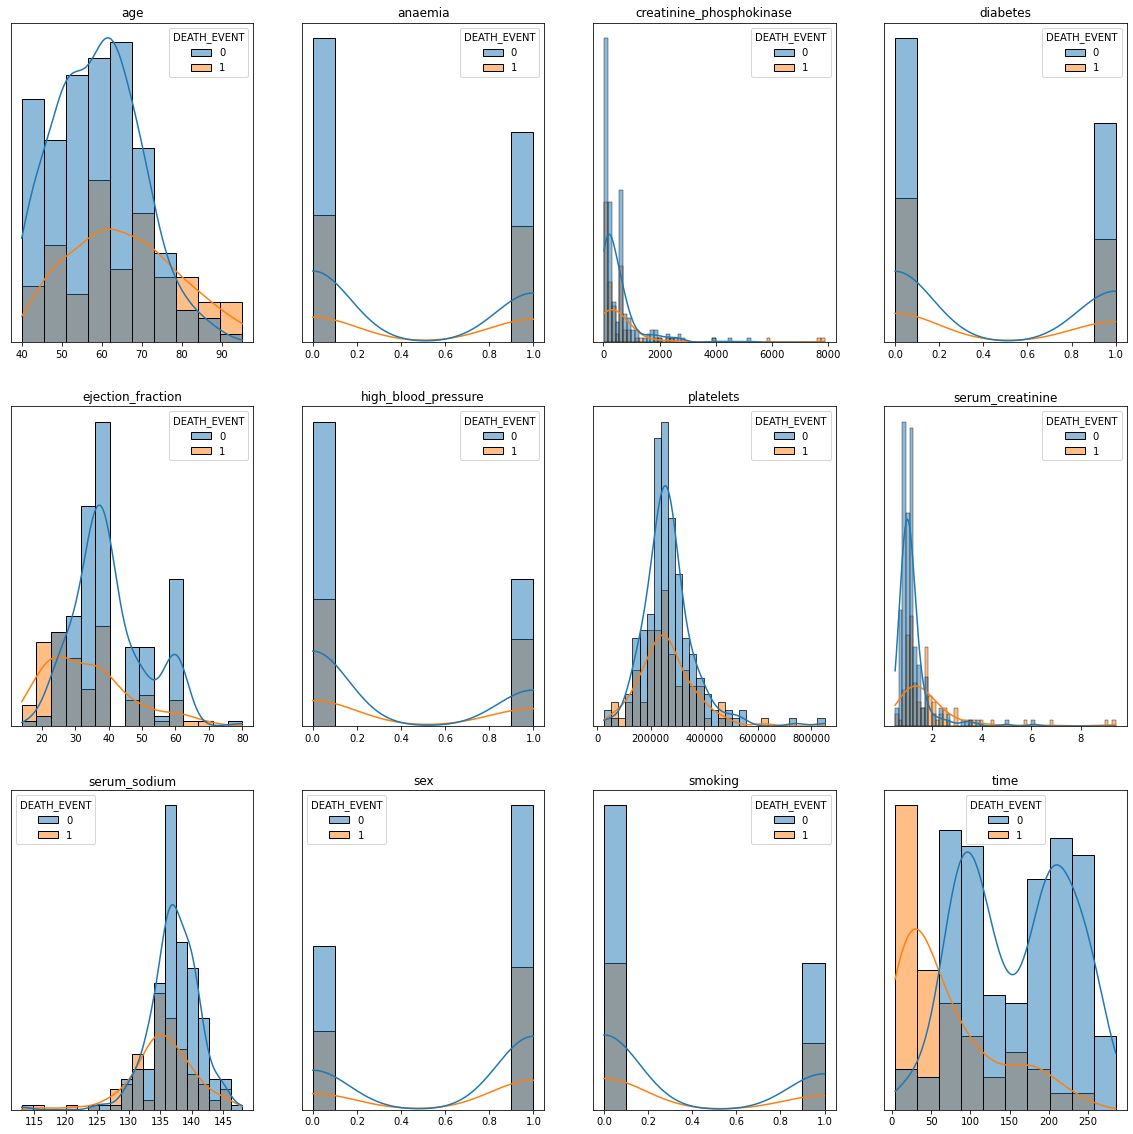

In [64]:
fig, ax = plt.subplots(3,4,figsize=(20,20))
idx = 0

for c in df.columns:
    if c == 'DEATH_EVENT':
        continue
    g = sns.histplot(x=c, data=df, hue='DEATH_EVENT',kde=True, ax=ax[idx//4, idx%4])
    idx += 1
    g.set_title(str(c))
    g.set_ylabel("")
    g.set_xlabel("")
    g.set_yticks([])
    

### 2-3 creatinine_phosphokinase 아웃라이어 제거

<AxesSubplot:xlabel='creatinine_phosphokinase', ylabel='Count'>

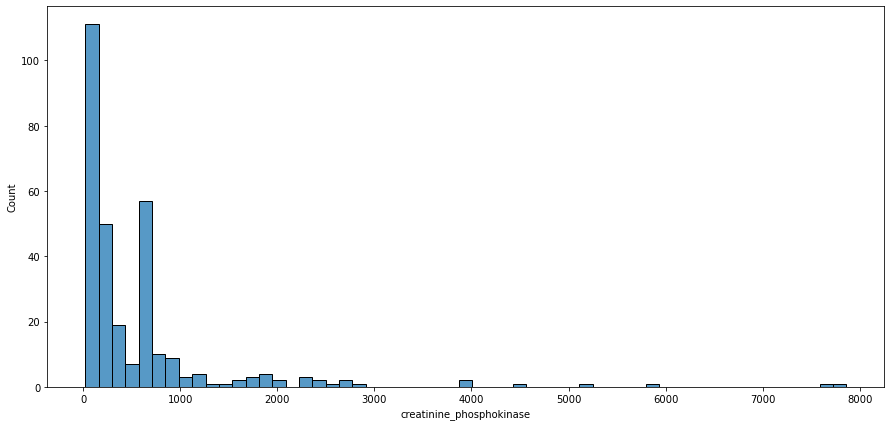

In [78]:
plt.figure(figsize=(15,7))
sns.histplot(data=df['creatinine_phosphokinase'])

In [79]:
# 3000 이하 확인
df.loc[df['creatinine_phosphokinase'] < 3000, 'creatinine_phosphokinase']

0       582
2       146
3       111
4       160
5        47
       ... 
294      61
295    1820
296    2060
297    2413
298     196
Name: creatinine_phosphokinase, Length: 292, dtype: int64

In [77]:
df.loc[df['creatinine_phosphokinase'] < 3000]

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.0,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.0,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.0,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.0,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.0,1.4,140,1,1,280,0


<AxesSubplot:xlabel='creatinine_phosphokinase', ylabel='Count'>

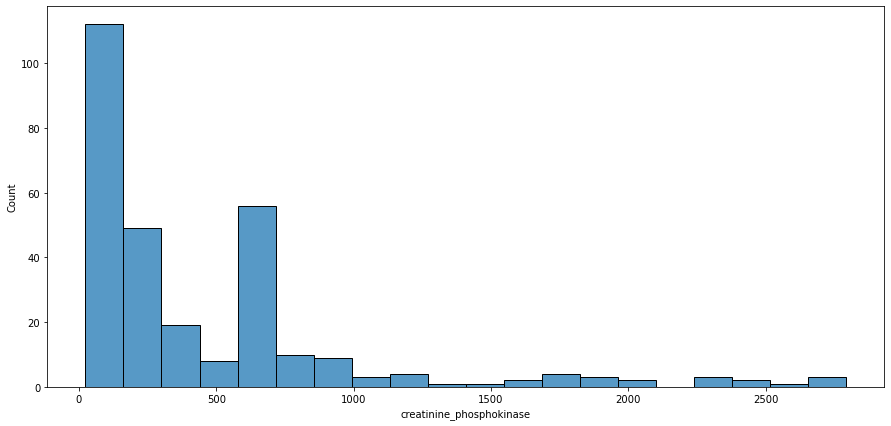

In [82]:
plt.figure(figsize=(15,7))
sns.histplot(data=df.loc[df['creatinine_phosphokinase'] < 3000, 'creatinine_phosphokinase'])

<AxesSubplot:xlabel='creatinine_phosphokinase', ylabel='Count'>

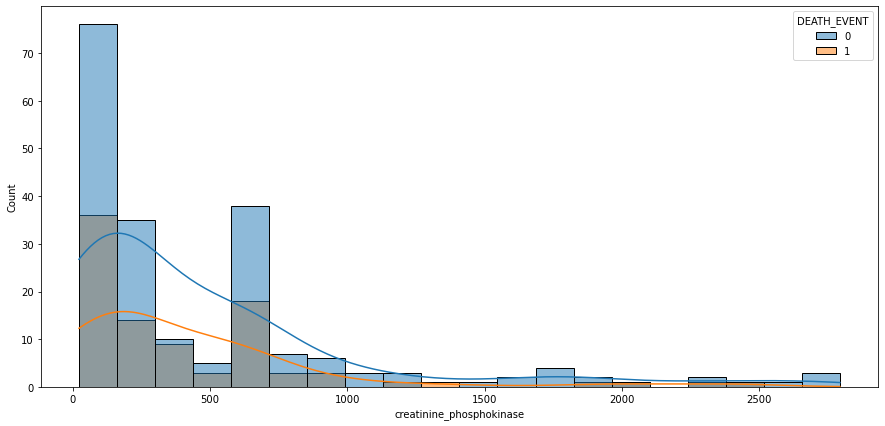

In [87]:
plt.figure(figsize=(15,7))
sns.histplot(x = 'creatinine_phosphokinase',data=df.loc[df['creatinine_phosphokinase']<3000] ,hue='DEATH_EVENT', kde=True)

In [88]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

### 2-4 ejection_fraction

<AxesSubplot:xlabel='ejection_fraction', ylabel='Count'>

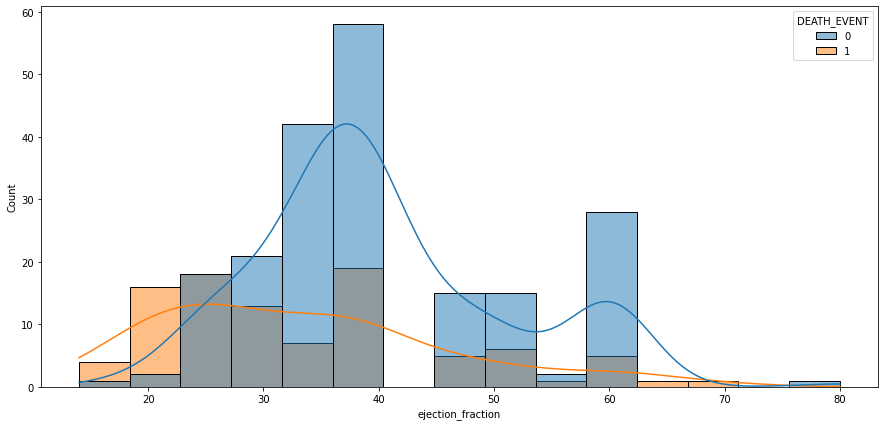

In [90]:
plt.figure(figsize=(15,7))
sns.histplot(x='ejection_fraction', data=df, hue='DEATH_EVENT', kde=True)

#### 40 ~ 45가 비어있음 -> Bin으로 조절가능

<AxesSubplot:xlabel='ejection_fraction', ylabel='Count'>

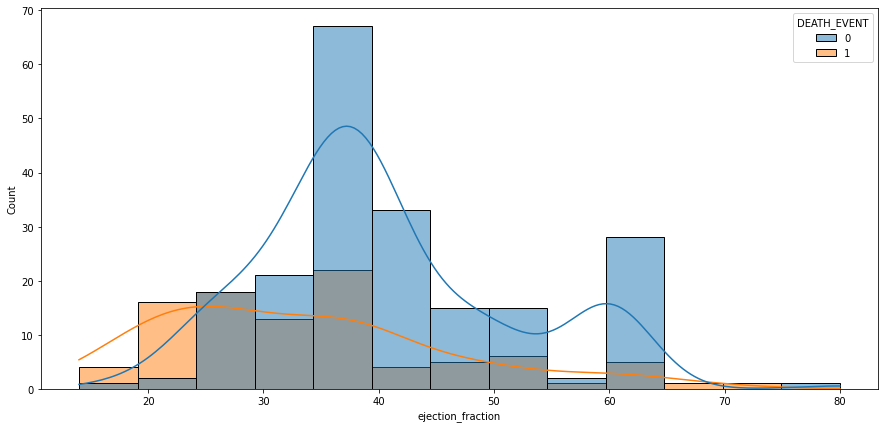

In [92]:
plt.figure(figsize=(15,7))
sns.histplot(x='ejection_fraction', data=df, hue='DEATH_EVENT', kde=True, bins=13)

#### Insight : ejection fraction 이 낮으면 사망율이 많음 / Precision을 높이는데 도움이 됨

### 2-5 platelets

<AxesSubplot:xlabel='platelets', ylabel='Count'>

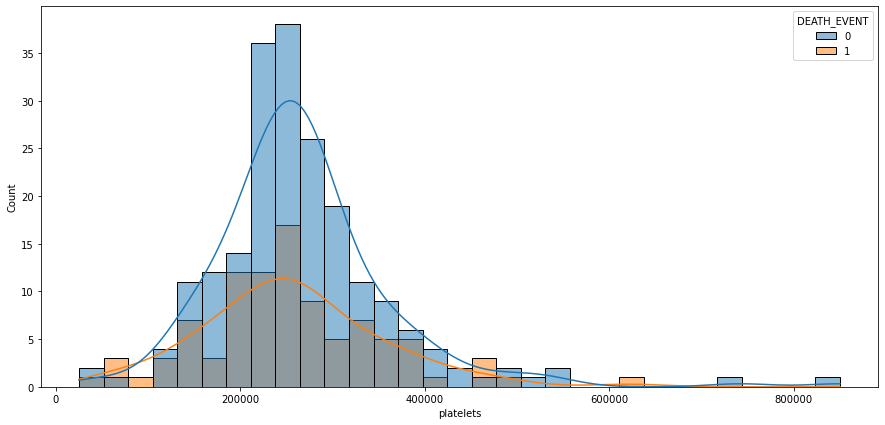

In [96]:
plt.figure(figsize=(15,7))
sns.histplot(x='platelets', data=df, hue='DEATH_EVENT', kde=True)

#### Insight : 통계적으로는 유용하나, Death Event에는 별로 쓸모가 없을 것 같음

### 2-6 time

<AxesSubplot:xlabel='time', ylabel='Count'>

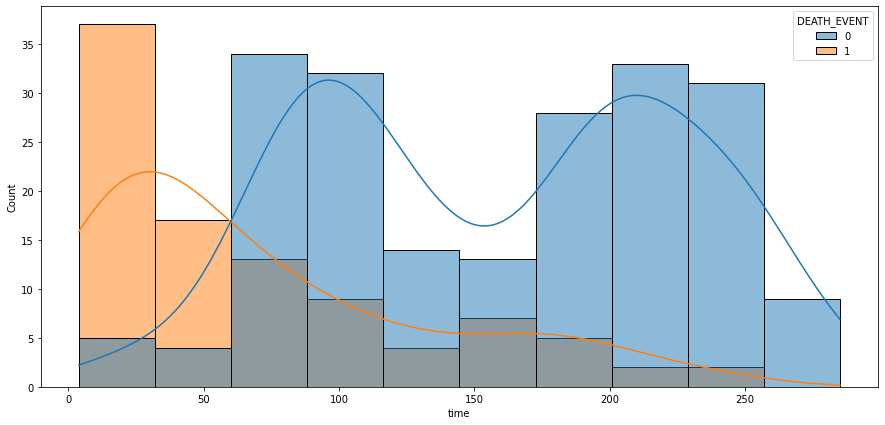

In [180]:
plt.figure(figsize=(15,7))
sns.histplot(x='time', data=df, hue='DEATH_EVENT', kde=True)

- 관찰초기에 사망하신 분이 많음 (감마 Distribution 형태로 나타남)
- Time을 배재하고 학습을 해야함

### 2-7 Jointplot

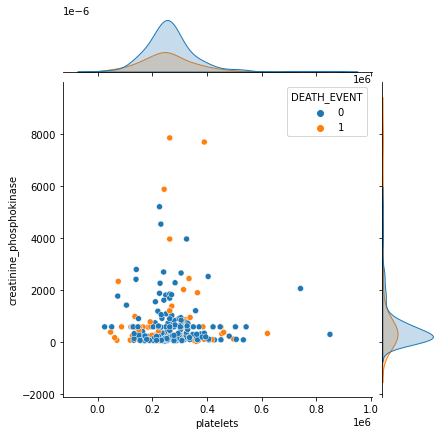

In [111]:
sns.jointplot(x='platelets', y='creatinine_phosphokinase', hue='DEATH_EVENT', data=df)

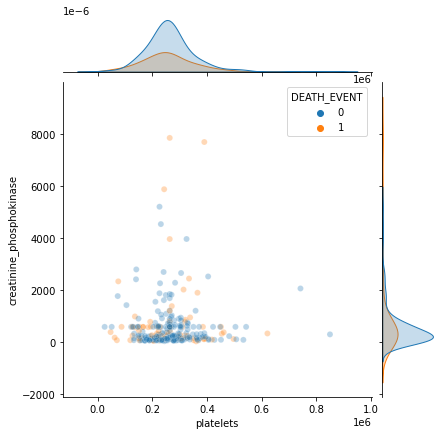

In [112]:
# Add alpha
sns.jointplot(x='platelets', y='creatinine_phosphokinase', hue='DEATH_EVENT', data=df, alpha=0.3)

### 2-7 Boxplot

<AxesSubplot:xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

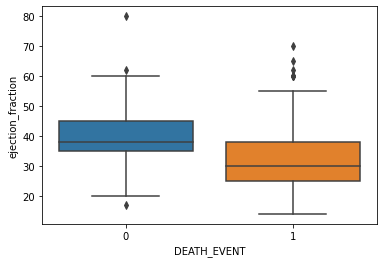

In [115]:
# 박스플랏이 받아둘이기 좀더 쉬움
sns.boxplot(x="DEATH_EVENT", y= 'ejection_fraction',data=df)

<AxesSubplot:xlabel='ejection_fraction', ylabel='Count'>

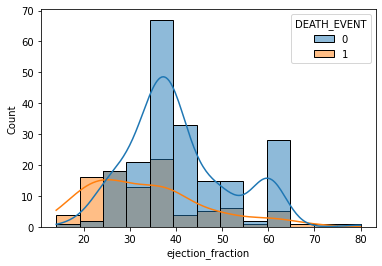

In [114]:
# histplot 과 비교
sns.histplot(x='ejection_fraction', data=df, hue='DEATH_EVENT', kde=True, bins=13)

<AxesSubplot:xlabel='smoking', ylabel='ejection_fraction'>

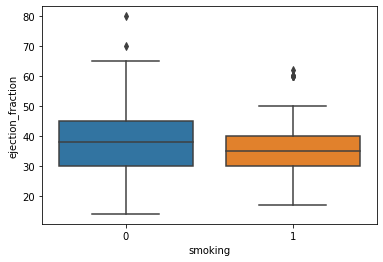

In [116]:
sns.boxplot(x='smoking', y='ejection_fraction', data=df)

<AxesSubplot:xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

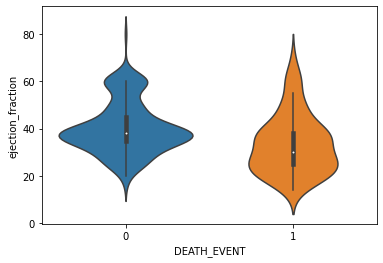

In [117]:
# histplot 과 boxplot을 동시에 볼 수 있음
sns.violinplot(x='DEATH_EVENT', y='ejection_fraction',data=df )

<AxesSubplot:xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

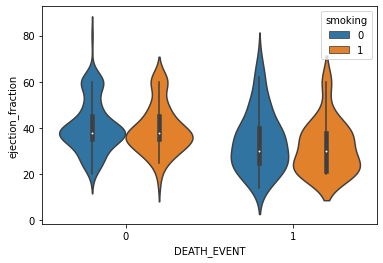

In [121]:
# hue를 추가
sns.violinplot(x='DEATH_EVENT', y='ejection_fraction',data=df, hue='smoking')

/Users/s107166/opt/anaconda3/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 9.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='DEATH_EVENT', ylabel='platelets'>

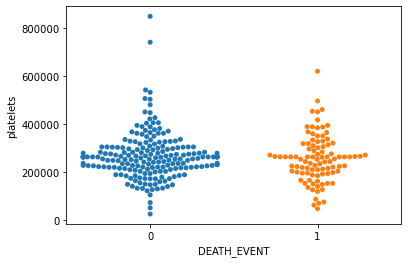

In [118]:
# scatter 와 violin이 합쳐진 모습
sns.swarmplot(x='DEATH_EVENT', y='platelets', data=df)

/Users/s107166/opt/anaconda3/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning: 9.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='DEATH_EVENT', ylabel='platelets'>

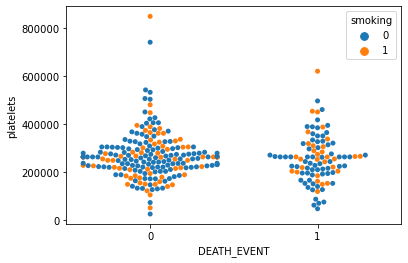

In [120]:
# hue를 추가함으로써 매우 강력해짐
sns.swarmplot(x='DEATH_EVENT', y='platelets', data=df, hue='smoking')

## Step 3. 모델 학습을 위한 데이터 전처리

In [122]:
from sklearn.preprocessing import StandardScaler

In [123]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

### 3-1 수치형 입력 데이터, 범주형 입력 데이터, 출력 데이터로 구분하기

In [181]:
# 수치형 입력 데이터, 범주형 입력 데이터, 출력 데이터로 구분하기
X_num = df[['age', 'creatinine_phosphokinase','ejection_fraction', 'platelets','serum_creatinine', 'serum_sodium']]
X_cat = df[['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']]
y = df['DEATH_EVENT']

In [182]:
X_num.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,75.0,582,20,265000.00,1.9,130
1,55.0,7861,38,263358.03,1.1,136
2,65.0,146,20,162000.00,1.3,129
3,50.0,111,20,210000.00,1.9,137
4,65.0,160,20,327000.00,2.7,116


In [183]:
X_cat.head()

,anaemia,diabetes,high_blood_pressure,sex,smoking
0,0,0,1,1,0
1,0,0,0,1,0
2,0,0,0,1,1
3,1,0,0,1,0
4,1,1,0,0,0


### 3-2 수치형 입력 데이터 전처리

In [184]:
# 수치형 입력 데이터를 전처리하고 입력 데이터 통합하기
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)

# Numpy의 Array 방식으로 변환되고 인덱스와 컬럼내용이 없음
X_scaled

array([[ 1.19294523e+00,  1.65728387e-04, -1.53055953e+00,
         1.68164843e-02,  4.90056987e-01, -1.50403612e+00],
       [-4.91279276e-01,  7.51463953e+00, -7.07675018e-03,
         7.53566018e-09, -2.84552352e-01, -1.41976151e-01],
       [ 3.50832977e-01, -4.49938761e-01, -1.53055953e+00,
        -1.03807313e+00, -9.09000174e-02, -1.73104612e+00],
       ...,
       [-1.33339153e+00,  1.52597865e+00,  1.85495776e+00,
         4.90208200e+00, -5.75030855e-01,  3.12043840e-01],
       [-1.33339153e+00,  1.89039811e+00, -7.07675018e-03,
        -1.26338936e+00,  5.92615005e-03,  7.66063830e-01],
       [-9.12335403e-01, -3.98321274e-01,  5.85388775e-01,
         1.34823057e+00,  1.99578485e-01, -1.41976151e-01]])

In [185]:
# index 와 컬럼 설정이 없을 시,
X_num_test = pd.DataFrame(data=X_scaled)
X_num_test

,0,1,2,3,4,5
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176
...,...,...,...,...,...,...
294,0.098199,-0.537688,-0.007077,-1.109765e+00,-0.284552,1.447094
295,-0.491279,1.278215,-0.007077,6.802472e-02,-0.187726,0.539054
296,-1.333392,1.525979,1.854958,4.902082e+00,-0.575031,0.312044
297,-1.333392,1.890398,-0.007077,-1.263389e+00,0.005926,0.766064


In [186]:
X_scaled = pd.DataFrame(data=X_scaled, index=X_num.index, columns=X_num.columns)
X_scaled

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176
...,...,...,...,...,...,...
294,0.098199,-0.537688,-0.007077,-1.109765e+00,-0.284552,1.447094
295,-0.491279,1.278215,-0.007077,6.802472e-02,-0.187726,0.539054
296,-1.333392,1.525979,1.854958,4.902082e+00,-0.575031,0.312044
297,-1.333392,1.890398,-0.007077,-1.263389e+00,0.005926,0.766064


### 3-3 스케일된 데이터와 category 데이터 결합

In [187]:
# 스케일된 데이터와 category 데이터를 합침
X = pd.concat([X_scaled, X_cat], axis=1)
X

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
0,1.192945,0.000166,-1.530560,1.681648e-02,0.490057,-1.504036,0,0,1,1,0
1,-0.491279,7.514640,-0.007077,7.535660e-09,-0.284552,-0.141976,0,0,0,1,0
2,0.350833,-0.449939,-1.530560,-1.038073e+00,-0.090900,-1.731046,0,0,0,1,1
3,-0.912335,-0.486071,-1.530560,-5.464741e-01,0.490057,0.085034,1,0,0,1,0
4,0.350833,-0.435486,-1.530560,6.517986e-01,1.264666,-4.682176,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.537688,-0.007077,-1.109765e+00,-0.284552,1.447094,0,1,1,1,1
295,-0.491279,1.278215,-0.007077,6.802472e-02,-0.187726,0.539054,0,0,0,0,0
296,-1.333392,1.525979,1.854958,4.902082e+00,-0.575031,0.312044,0,1,0,0,0
297,-1.333392,1.890398,-0.007077,-1.263389e+00,0.005926,0.766064,0,0,0,1,1


### 3-4 학습데이터와 테스트데이터 분리하기

In [188]:
from sklearn.model_selection import train_test_split

In [189]:
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
# shuffle = False일 경우, 앞에서부터 순차적으로 잘라서 사용됨
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [190]:
X_train

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
14,-0.996547,-0.518074,-0.684180,1.675963,-0.381379,0.312044,1,0,1,0,0
210,0.771889,-0.381804,-1.784473,1.286781,-0.381379,-0.141976,0,1,1,1,1
236,1.192945,-0.477812,1.008578,-0.157292,-0.284552,2.582144,0,0,1,1,0
44,-0.070223,0.006360,1.854958,-0.710340,-0.284552,1.220084,1,1,0,0,0
163,-0.912335,1.808842,-0.260991,-1.929096,-0.478205,1.220084,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
203,-0.070223,-0.539753,-1.107370,-0.525991,2.039276,-0.141976,0,0,1,1,1
255,-0.743913,-0.403483,-0.684180,0.723490,-0.381379,1.220084,1,1,1,1,1
72,2.035057,5.471619,-0.260991,-0.208500,-0.381379,-1.050016,0,0,0,1,1
235,1.361368,-0.488136,1.008578,1.460889,-0.284552,0.085034,1,0,1,1,0


In [191]:
y_train

14     0
210    0
236    0
44     1
163    1
      ..
203    0
255    0
72     1
235    0
37     1
Name: DEATH_EVENT, Length: 209, dtype: int64

## Step 4. Classification 모델 학습하기

### 4-1  Logistic Regression 모델 생성/학습하기

In [192]:
from sklearn.linear_model import LogisticRegression

In [193]:
# LogisticRegression 모델 생성/학습
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### 4-2 모델 학습 결과 평가하기

In [194]:
from sklearn.metrics import classification_report

In [195]:
# Predict를 수행하고 classification_report() 결과 출력하기
pred = model_lr.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.92      0.84        64
           1       0.64      0.35      0.45        26

    accuracy                           0.76        90
   macro avg       0.71      0.63      0.65        90
weighted avg       0.74      0.76      0.73        90



f1-score은 종합평균임

### 4-3  XGBoost 모델 생성/학습하기

In [196]:
from xgboost import XGBClassifier

In [197]:
# XGBClassifier 모델 생성/학습
model_xgb = XGBClassifier()
model_xgb.fit(X_train, y_train)

[17:23:14] WARNING: /Users/travis/build/dmlc/xgboost/src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


/Users/s107166/opt/anaconda3/lib/python3.8/site-packages/xgboost/sklearn.py:888: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=12, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [198]:
# Predict를 수행하고 classification_report() 결과 출력하기
pred = model_xgb.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84        64
           1       0.62      0.50      0.55        26

    accuracy                           0.77        90
   macro avg       0.72      0.69      0.70        90
weighted avg       0.76      0.77      0.76        90



Accuracy가 0.77 정도의 정확도를 갖음

### 4-4 특징의 중요도 확인하기

In [199]:
# XGBClassifier 모델의 feature_importances_를 이용하여 중요도 plot
model_xgb.feature_importances_

array([0.11346674, 0.0805041 , 0.12799399, 0.07096241, 0.15720052,
       0.09786253, 0.05725832, 0.05873214, 0.07331295, 0.08166528,
       0.08104102], dtype=float32)

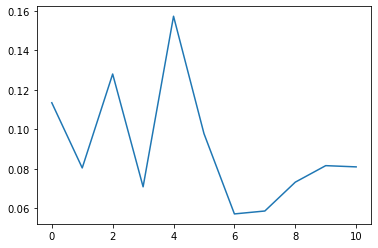

In [200]:
plt.plot(model_xgb.feature_importances_)

5번째 feature 가 중요하다는 것을 알 수 있음

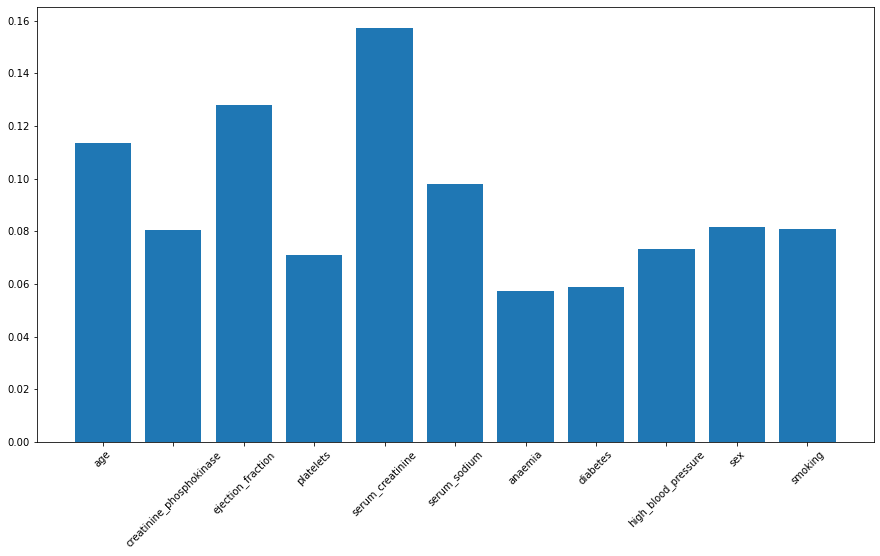

In [201]:
plt.figure(figsize=(15,8))
plt.bar(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation=45)
plt.show()

## Step5 모델 학습 결과 심화 분석하기

### 5-1 JointPlot으로 중요한 feature 사이의 관계 확인

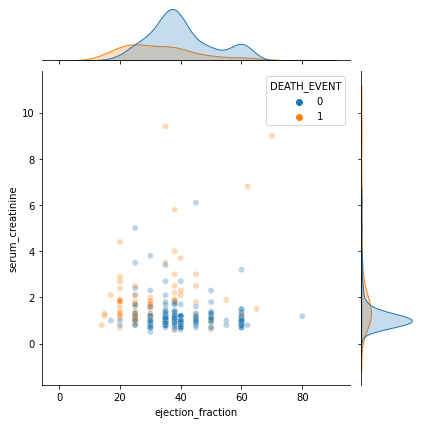

In [202]:
# Joint Plot []
sns.jointplot(x='ejection_fraction', y='serum_creatinine', hue='DEATH_EVENT', data=df, alpha=0.3)

Death event를 선을 그어서 구별이 가능함

### 5-2 Precision-Recall 커브 확인하기

In [208]:
from sklearn.metrics import plot_precision_recall_curve

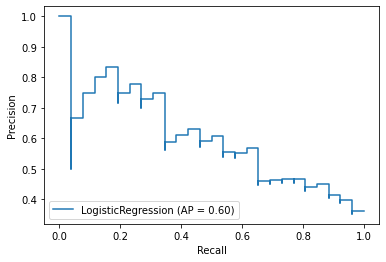

In [206]:
# 두 모델의 Precision-Recall 커브를 한번에 그리기 (힌트: fig.gca()로 ax를 반환받아 사용)
plot_precision_recall_curve(model_lr, X_test, y_test)


AP가 1에 가까울수록 좋음

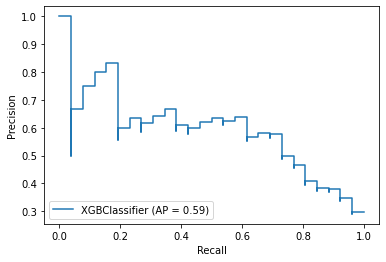

In [207]:
plot_precision_recall_curve(model_xgb, X_test, y_test)

### 5-3 Precision-Recall 커브 겹치기

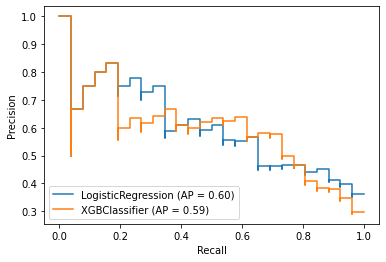

In [210]:
fig = plt.figure() #큰 화면을 하나 잡고
ax = fig.gca() # 그 화면의 X축을 하나 잡아서
plot_precision_recall_curve(model_lr, X_test, y_test, ax=ax) # 같은 X 축에 그려줌
plot_precision_recall_curve(model_xgb, X_test, y_test, ax=ax)

### 5-4 ROC 커브 확인

In [211]:
from sklearn.metrics import plot_roc_curve

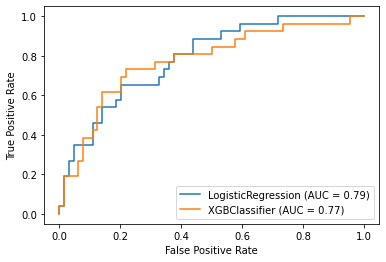

In [213]:
# 두 모델의 ROC 커브를 한번에 그리기 (힌트: fig.gca()로 ax를 반환받아 사용)

fig = plt.figure() #큰 화면을 하나 잡고
ax = fig.gca() # 그 화면의 X축을 하나 잡아서
plot_roc_curve(model_lr, X_test, y_test, ax=ax) # 같은 X 축에 그려줌
plot_roc_curve(model_xgb, X_test, y_test, ax=ax)

True Positive 가 얼마나 빨리 1에 도달하는지를 확인함